# Customer Churn - Exploratory Data Analysis

## Objective

To understand **key factors** affecting customer churn and extract insights for feature engineering and modelling.

---

## Key Questions
- What type of customers are more likely to churn?
- Does contract type affect churn?
- How do charges and tenure influence churn?

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set(style= "whitegrid")

## Load Dataset

In [11]:
print("Loading dataset")
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Dataset load complete\n")

Loading dataset
Dataset load complete



In [12]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Basic inspection

In [13]:
df.shape

(7043, 21)

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [19]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


## Missing values check

In [18]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [17]:
# Fix TotalCharges column issue (str -> numeric)
print("Fixing TotalCharges column issue (str -> numeric)")
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors= 'coerce')
print("Fixing complete")

df['TotalCharges'].isnull().sum()

Fixing TotalCharges column issue (str -> numeric)
Fixing complete


np.int64(11)

In [20]:
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace= True)

/tmp/ipykernel_270136/223956645.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace= True)


0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

## Target Variable Analysis

In [21]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

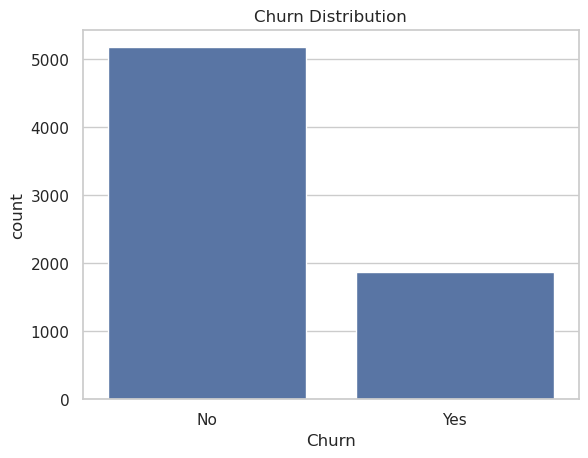

In [22]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

As we can see, data is imbalanced, with most values being non churn values.

## Categorical feature analysis

### Contract type vs churn

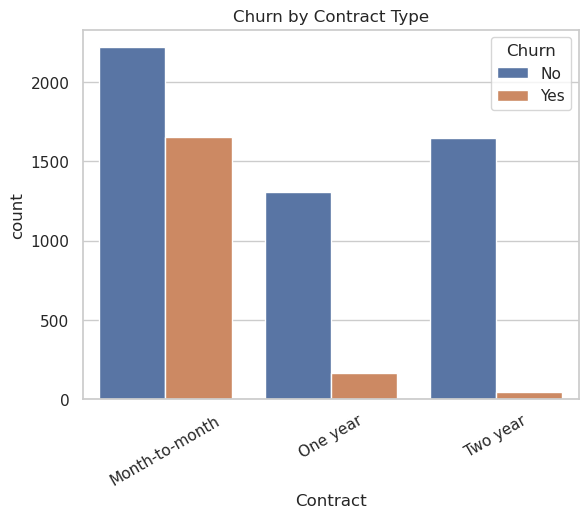

In [23]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn by Contract Type")
plt.xticks(rotation=30)
plt.show()

Month-to-month customers churn more, two year contracted customers churn less.

### Internet Service vs Churn

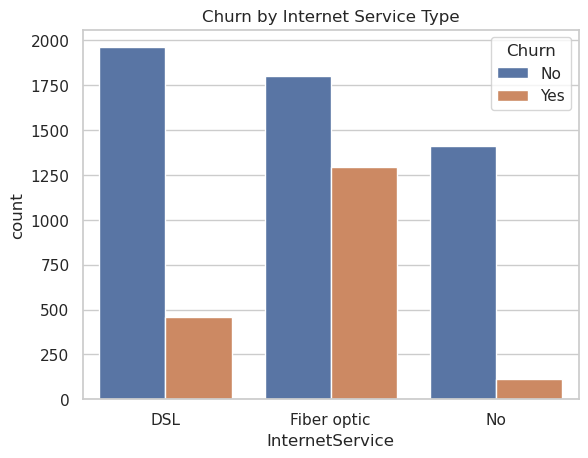

In [25]:
sns.countplot(x= "InternetService", hue= "Churn", data= df)
plt.title("Churn by Internet Service Type")
plt.show()

Customers with Fiber Optic internet services churn more. Those with no internet service churn least.

### Payment Method vs Churn

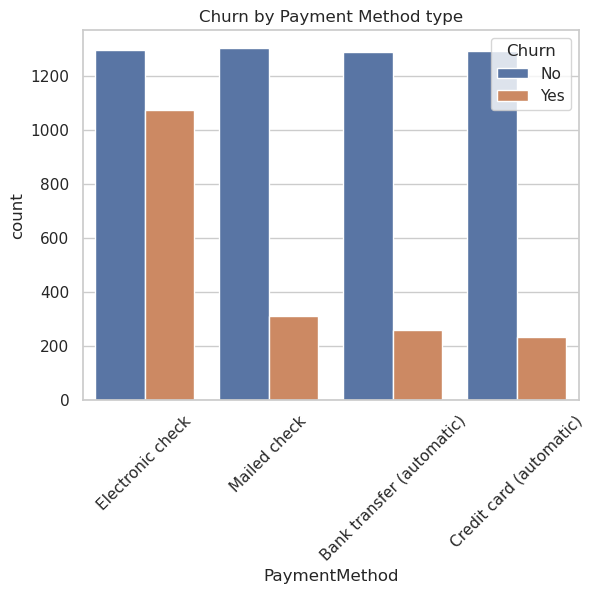

In [27]:
sns.countplot(x= "PaymentMethod", hue= "Churn", data= df)
plt.title("Churn by Payment Method type")
plt.xticks(rotation= 45)
plt.show()

Customers with electronic checks churn the most.

## Numerical Feature Analysis

### Tenure Distribution

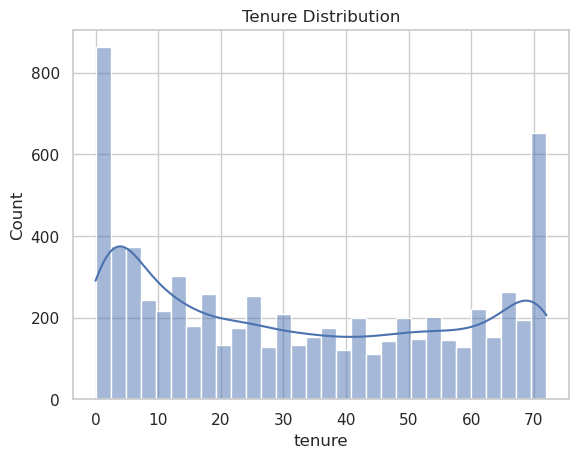

In [28]:
sns.histplot(df['tenure'], bins=30, kde=True)
plt.title("Tenure Distribution")
plt.show()

### Monthly Charges vs Churn

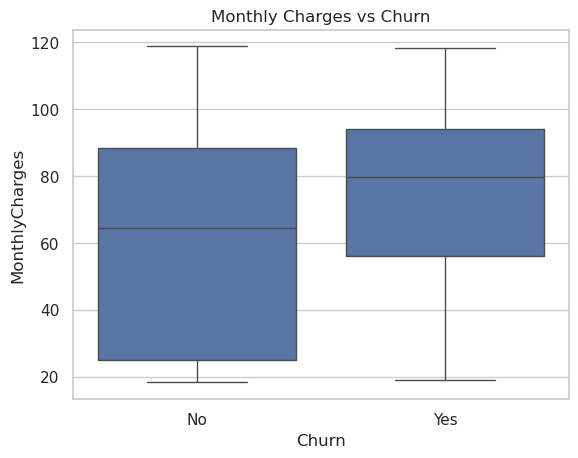

In [30]:
sns.boxplot(x= "Churn", y= "MonthlyCharges", data= df)
plt.title("Monthly Charges vs Churn")
plt.show()

Higher monthly charges may correlate with churn

### Total Charges vs Churn

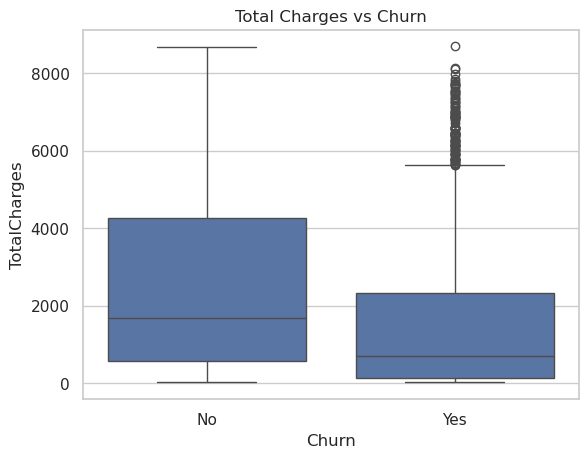

In [31]:
sns.boxplot(x='Churn', y='TotalCharges', data=df)
plt.title("Total Charges vs Churn")
plt.show()

### Correlation Heatmap

/tmp/ipykernel_270136/628490076.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_encoded.select_dtypes(include='object').columns:


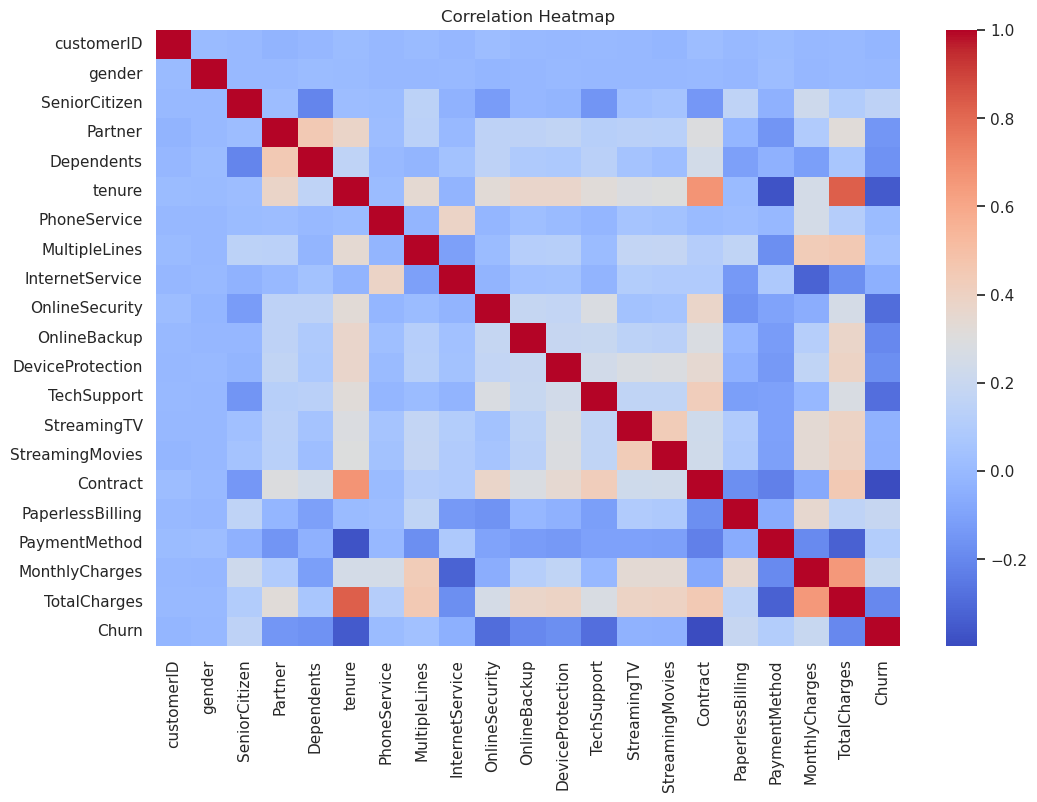

In [32]:
# Convert categorical to numeric for correlation
df_encoded = df.copy()

for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

plt.figure(figsize=(12,8))
sns.heatmap(df_encoded.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Key Insights

1. Customers with month-to-month contracts have higher churn rates.
2. Short tenure customers are more likely to churn.
3. Higher monthly charges correlate with higher churn.
4. Certain payment methods (e.g., electronic check) show higher churn.

---

## Feature Engineering Ideas

- Create tenure groups (low, medium, high)
- Encode contract type carefully
- Combine charges-related features